# Linear Regression from Scratch – House Price Prediction  
**Ordinary Least Squares Implementation – Machine Learning Lab**

**Objective**  
Implement **Ordinary Least Squares (OLS) Linear Regression** from scratch using the normal equation and apply it to a classic real-world regression task: **predicting house prices** based on structural and locational features.

**Dataset**  
- **Boston Housing Dataset** (UCI Machine Learning Repository, 1978)  
- 506 samples, 13 features (e.g., average rooms, crime rate, pupil-teacher ratio, accessibility to highways)  
- Target: MEDV – Median value of owner-occupied homes in $1000s  
- Direct link: https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv  
- Classic benchmark dataset with interpretable features and some multicollinearity

**What this notebook demonstrates**  
- Loading and exploring real tabular data  
- Basic EDA: correlation heatmap to understand feature relationships  
- Feature scaling for better coefficient interpretation  
- Scratch implementation using normal equation (closed-form solution)  
- Comparison with scikit-learn’s LinearRegression  
- Evaluation metrics: MSE, RMSE, R²  
- Diagnostic plots: Actual vs Predicted + Residual plot (to check assumptions)

**Key Learning Outcomes**  
- Derive and implement the exact OLS solution (no gradient descent needed)  
- Understand impact of multicollinearity and feature scaling  
- Interpret coefficients in a real-estate context (e.g., more rooms → higher price)  
- Recognize model limitations (linear assumption, old data, omitted variables)


In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression as SklearnLR
from sklearn.preprocessing import StandardScaler

In [3]:
# ── 1. Load real Boston Housing dataset ─────────────────────────
print("Loading Boston Housing dataset...")
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print("Columns:", df.columns.tolist())
print(df.head(3))
print("\nMissing values:\n", df.isnull().sum())

Loading Boston Housing dataset...
Dataset shape: (506, 14)
Columns: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  

Missing values:
 crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [5]:
# Target: MEDV
X = df.drop('medv', axis=1)
y = df['medv'] * 1000

In [6]:
# Feature names for interpretation
feature_names = X.columns.tolist()

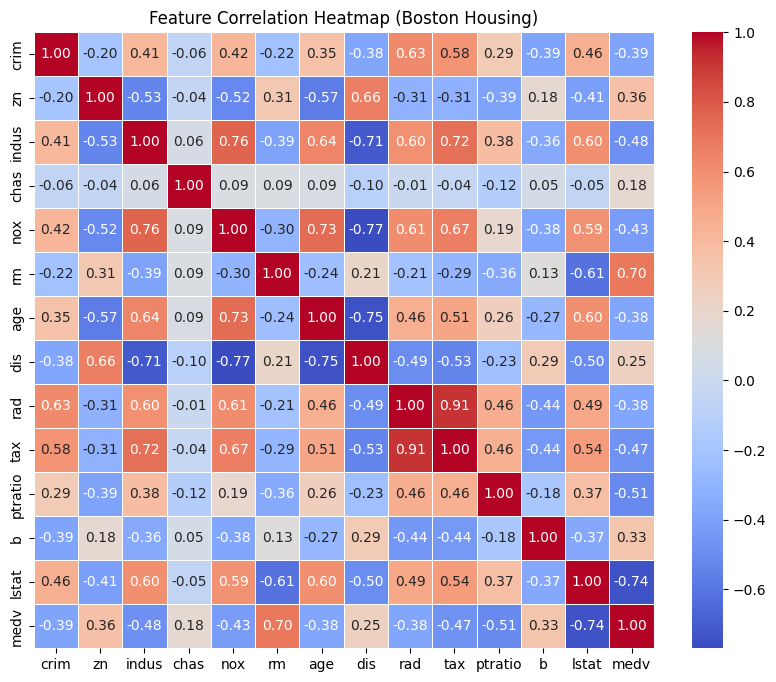

In [7]:
# ── 2. Quick EDA: Correlation heatmap ───────────────────────────
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap (Boston Housing)")
plt.show()

In [8]:
# ── 3. Train/Test split + Scaling (helps interpretation) ────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")

Train samples: 379 | Test samples: 127


In [10]:
# ── 4. Scratch Linear Regression (Normal Equation) ──────────────
class LinearRegressionScratch:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        theta_best = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
        self.intercept_ = theta_best[0]
        self.coef_ = theta_best[1:]

    def predict(self, X):
        return X @ self.coef_ + self.intercept_

In [11]:
# Train scratch model
model_scratch = LinearRegressionScratch()
model_scratch.fit(X_train_scaled, y_train)
y_pred_scratch = model_scratch.predict(X_test_scaled)

In [12]:
# ── 5. scikit-learn comparison ──────────────────────────────────
model_sk = SklearnLR()
model_sk.fit(X_train_scaled, y_train)
y_pred_sk = model_sk.predict(X_test_scaled)

In [13]:
# ── 6. Evaluation ───────────────────────────────────────────────
def print_metrics(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{label}")
    print(f"  MSE  : {mse:,.0f}")
    print(f"  RMSE : {rmse:,.0f}  (typical error in $)")
    print(f"  R²   : {r2:.4f}")

print_metrics(y_test, y_pred_scratch, "Scratch Implementation (Normal Equation)")
print("  Intercept:", f"{model_scratch.intercept_:,.1f}")
print("  Coefficients:")
for name, coef in zip(feature_names, np.round(model_scratch.coef_, 3)):
    print(f"    {name:>12}: {coef:>8}")

print_metrics(y_test, y_pred_sk, "scikit-learn LinearRegression (validation)")
print("  Intercept:", f"{model_sk.intercept_:,.1f}")


Scratch Implementation (Normal Equation)
  MSE  : 22,098,695
  RMSE : 4,701  (typical error in $)
  R²   : 0.6844
  Intercept: 22,907.9
  Coefficients:
            crim: -1065.464
              zn:   681.55
           indus:  339.288
            chas:  737.263
             nox: -1931.781
              rm: 3141.727
             age: -255.863
             dis: -2955.61
             rad: 2214.161
             tax: -1651.273
         ptratio: -2087.149
               b: 1152.357
           lstat: -3695.042

scikit-learn LinearRegression (validation)
  MSE  : 22,098,695
  RMSE : 4,701  (typical error in $)
  R²   : 0.6844
  Intercept: 22,907.9


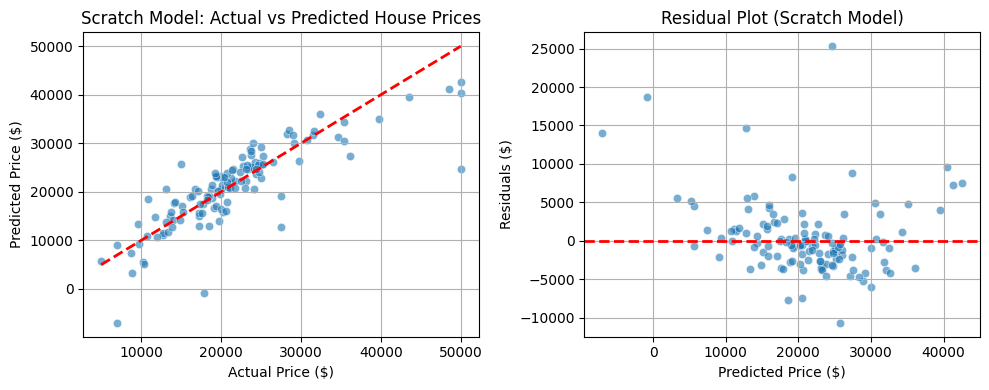

In [17]:
# ── 7. Visualizations ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred_scratch, alpha=0.6, ax=axes[0])
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].set_title("Scratch Model: Actual vs Predicted House Prices")
axes[0].grid(True)

# Residual plot (important diagnostic)
residuals = y_test - y_pred_scratch
sns.scatterplot(x=y_pred_scratch, y=residuals, alpha=0.6, ax=axes[1])
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel("Predicted Price ($)")
axes[1].set_ylabel("Residuals ($)")
axes[1].set_title("Residual Plot (Scratch Model)")
axes[1].grid(True)

plt.tight_layout()
plt.show()